# Regional Pacific phytoplankton size

Regional counterpart of `National/biochemistry/c_phytoplankton.ipynb`. The workflow maps the
mean, seasonal cycle, anomalies and linear trend of **Median phytoplankton size**, overlays
Pacific EEZ boundaries, calculates area-weighted regional and EEZ summaries, and
compares ENSO phases using the project's five-consecutive-month ONI rule.

In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings('ignore')

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.path import Path as MplPath
from scipy import stats

root_candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
repo_root = next((p for p in root_candidates if (p / 'functions').is_dir() and (p / 'data').is_dir()), None)
if repo_root is None:
    raise FileNotFoundError('Run this notebook from inside the CIndRA repository.')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from functions.data_downloaders import download_oni_index
from functions.ocean import process_trend_with_nan

plt.rcParams.update({'font.size': 12, 'axes.titlesize': 15, 'axes.labelsize': 14,
                     'xtick.labelsize': 12, 'ytick.labelsize': 12,
                     'legend.fontsize': 13})

## 1. Configuration and data

Regional NetCDF files are cached at `data/regional/biochemistry/`. The source is
downloaded automatically when absent. National subsets are never used in this
regional workflow. Coordinates may be named `lon`/`lat` or
`longitude`/`latitude`.

In [2]:
variable = 'MD50'
label = 'Median phytoplankton size'
units = 'µm'
cmap = 'viridis'
pacific_extent = (125, 245, -35, 35)
trend_period = (1998, 2025)
reference_period = (1998, 2020)
regional_file = 'MD50_pacific_monthly.nc'
data_dir = repo_root / 'data'
regional_dir = data_dir / 'regional' / 'biochemistry'
fig_dir = repo_root / 'matrix_cc' / 'figures'
regional_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

eez_file = data_dir / 'regional' / 'Pacific_EEZs' / 'Pacific_EEZs.shp'
if not eez_file.is_file():
    raise FileNotFoundError(f'Pacific EEZ shapefile not found: {eez_file}')

regional_path = regional_dir / regional_file

### Automatic regional MD50 download

When the cache is absent, the next cell downloads the NOAA PIFSC
`md50_exp_2025` product in short time blocks and combines them. The native
0.05° grid is sampled every 20 cells (1°) to avoid proxy timeouts and keep
the regional file compact. Existing valid blocks and the final cache are
reused, so an interrupted download can be resumed.

In [3]:
import time
from urllib.parse import quote

import requests

md50_base_url = 'https://oceanwatch.pifsc.noaa.gov/erddap/griddap/md50_exp_2025.nc'
download_start_year = 1998
download_end_year = 2025
spatial_stride = 20  # native 0.05° × 20 = 1°
download_extent = (125, 245, -20, 35)  # constrained by product coverage
block_years = 5

def md50_block_url(first_year, last_year):
    west, east, south, north = download_extent
    constraint = (
        f'[(%s-01-01T00:00:00Z):1:(%s-12-01T00:00:00Z)]'
        f'[(%s):%s:(%s)][(%s):%s:(%s)]'
        % (first_year, last_year, south, spatial_stride, north,
           west, spatial_stride, east)
    )
    return md50_base_url + '?MD50' + quote(constraint, safe='():')

def download_with_retries(url, destination, attempts=4):
    temporary = destination.with_suffix(destination.suffix + '.part')
    for attempt in range(1, attempts + 1):
        try:
            with requests.get(url, stream=True, timeout=(30, 300)) as response:
                response.raise_for_status()
                with temporary.open('wb') as stream:
                    for chunk in response.iter_content(chunk_size=1024 * 1024):
                        if chunk:
                            stream.write(chunk)
            temporary.replace(destination)
            return
        except (requests.RequestException, OSError):
            if attempt == attempts:
                raise
            time.sleep(5 * attempt)

if not regional_path.is_file():
    block_paths = []
    for first in range(download_start_year, download_end_year + 1, block_years):
        last = min(first + block_years - 1, download_end_year)
        block = regional_dir / f'MD50_pacific_{first}_{last}.nc'
        block_paths.append(block)
        if not block.is_file():
            print(f'Downloading MD50 {first}–{last} ...')
            download_with_retries(md50_block_url(first, last), block)

    pieces = []
    for block in block_paths:
        with xr.open_dataset(block) as source:
            pieces.append(source.load())
    combined = xr.concat(pieces, dim='time').sortby('time')
    combined = combined.isel(time=~combined.get_index('time').duplicated())
    final_temporary = regional_path.with_suffix('.nc.part')
    combined.to_netcdf(final_temporary)
    final_temporary.replace(regional_path)
    for block in block_paths:
        block.unlink(missing_ok=True)
    print(f'Created regional cache: {regional_path}')
else:
    print(f'Using cached regional MD50: {regional_path}')

Using cached regional MD50: /Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Projects/CC_indicators/PICCM/CIndRA/data/regional/biochemistry/MD50_pacific_monthly.nc


In [4]:
if not regional_path.is_file():
    raise FileNotFoundError(
        f'Regional download is missing: {regional_path}. '
        'Review the download-cell output before continuing.'
    )
source_path = regional_path
is_regional_dataset = True
print('Data:', source_path)
print('Source: NOAA PIFSC experimental MD50 product')
print('Reference: https://oceanwatch.pifsc.noaa.gov/erddap/info/md50_exp_2025/index.html')

Data: /Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Projects/CC_indicators/PICCM/CIndRA/data/regional/biochemistry/MD50_pacific_monthly.nc
Source: NOAA PIFSC experimental MD50 product
Reference: https://oceanwatch.pifsc.noaa.gov/erddap/info/md50_exp_2025/index.html


In [5]:
ds = xr.open_dataset(source_path)
rename = {}
if 'lon' in ds.coords: rename['lon'] = 'longitude'
if 'lat' in ds.coords: rename['lat'] = 'latitude'
ds = ds.rename(rename)
if variable not in ds:
    raise KeyError(f'{variable!r} is not present in {source_path.name}: {list(ds.data_vars)}')
if 'depth' in ds[variable].dims:
    ds = ds.isel(depth=0, drop=True)
field = ds[variable].sortby('time').sortby('latitude').sortby('longitude')
field = field.sel(time=slice(str(trend_period[0]), str(trend_period[1])))
field = field.where(np.isfinite(field))

eez = gpd.read_file(eez_file).to_crs(4326)
country_col = next((c for c in ('Country', 'GEONAME', 'SOVEREIGN1', 'TERRITORY1') if c in eez.columns), None)
if country_col is None:
    eez['Country'] = eez.index.astype(str)
    country_col = 'Country'

data_extent = (float(field.longitude.min()), float(field.longitude.max()),
               float(field.latitude.min()), float(field.latitude.max()))
map_extent = pacific_extent if is_regional_dataset else data_extent
print(f'Coverage: {data_extent}; {field.sizes["time"]} months')

Coverage: (125.0, 245.0, -20.0, 35.0); 336 months


## 2. Map helpers and long-term mean

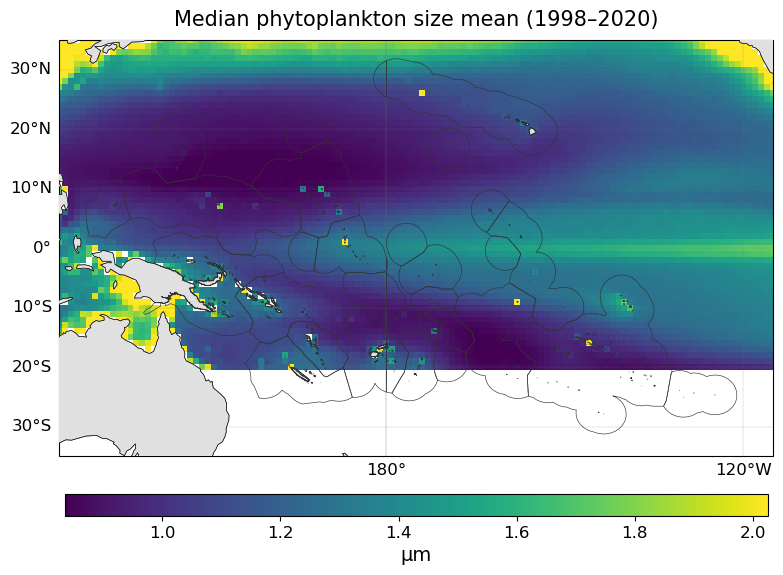

In [6]:
def setup_map(ax, title):
    ax.set_extent(map_extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='0.88', edgecolor='0.35', linewidth=0.4, zorder=3)
    ax.coastlines(linewidth=0.45, zorder=4)
    eez.boundary.plot(ax=ax, transform=ccrs.PlateCarree(), color='0.2', linewidth=0.45, zorder=5)
    gl = ax.gridlines(draw_labels=True, linewidth=0.25, color='0.45', alpha=0.5)
    gl.top_labels = gl.right_labels = False
    ax.set_title(title, pad=10)
    return ax

def map_field(values, title, colour_map, cbar_label, symmetric=False):
    finite = np.asarray(values.values)[np.isfinite(values.values)]
    if not len(finite):
        raise ValueError('No finite values are available for this map.')
    if symmetric:
        lim = float(np.nanpercentile(np.abs(finite), 98))
        vmin, vmax = -lim, lim
    else:
        vmin, vmax = np.nanpercentile(finite, [2, 98])
    fig, ax = plt.subplots(figsize=(15, 6), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
    setup_map(ax, title)
    im = ax.pcolormesh(values.longitude, values.latitude, values, transform=ccrs.PlateCarree(),
                       cmap=colour_map, vmin=vmin, vmax=vmax, shading='auto')
    cb = fig.colorbar(
        im, ax=ax, orientation='horizontal', pad=0.07,
        shrink=0.48, aspect=32,
    )
    cb.set_label(cbar_label, fontsize=14)
    fig.tight_layout()
    return fig

climatology = field.sel(time=slice(str(reference_period[0]), str(reference_period[1]))).mean('time')
fig_mean = map_field(climatology, f'{label} mean ({reference_period[0]}–{reference_period[1]})', cmap, units)
fig_mean.savefig(fig_dir / f'regional_{variable}_mean.png', dpi=180, bbox_inches='tight')

## 3. Linear trend

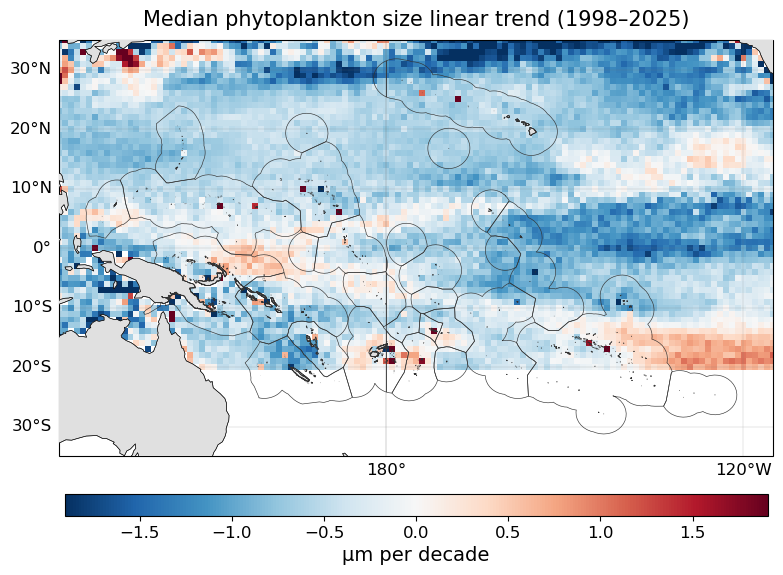

In [7]:
annual = field.resample(time='YS').mean()
trend, _, _, _, _ = process_trend_with_nan(annual)
trend = xr.DataArray(trend * 10, coords={'latitude': annual.latitude, 'longitude': annual.longitude},
                     dims=('latitude', 'longitude'))
fig_trend = map_field(trend, f'{label} linear trend ({trend_period[0]}–{trend_period[1]})',
                      'RdBu_r', f'{units} per decade', symmetric=True)
fig_trend.savefig(fig_dir / f'regional_{variable}_trend.png', dpi=180, bbox_inches='tight')

## 4. Seasonal climatology and anomalies

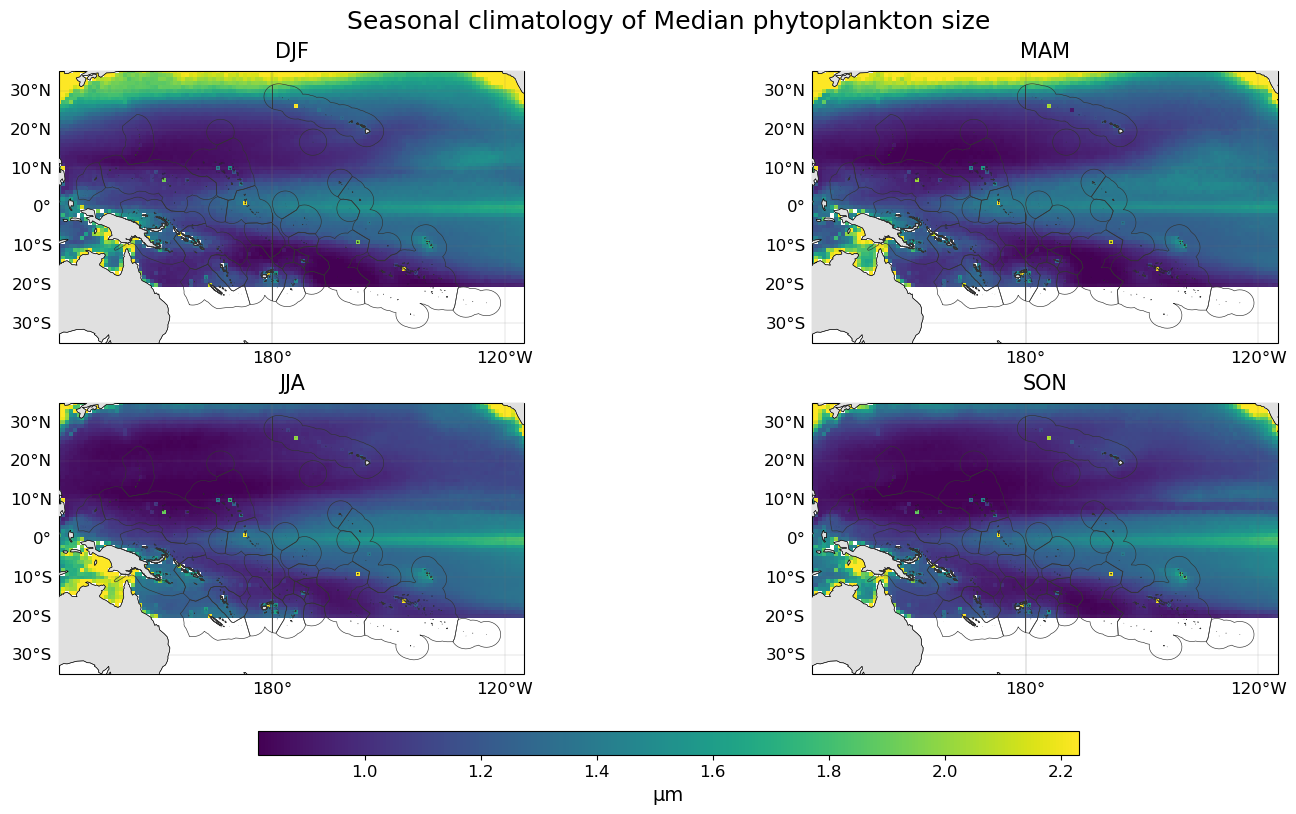

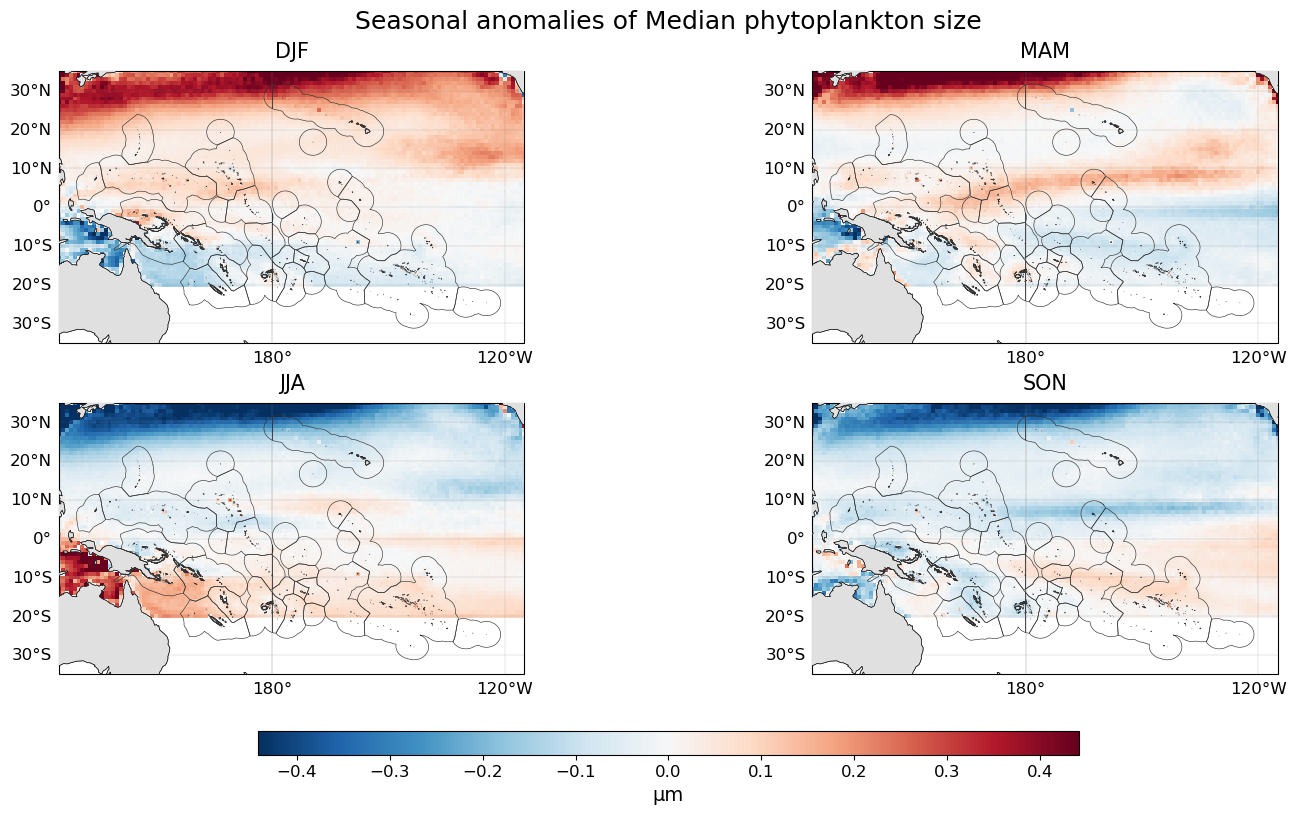

In [8]:
seasonal = field.groupby('time.season').mean().sel(season=['DJF', 'MAM', 'JJA', 'SON'])
seasonal_anomaly = seasonal - climatology

def seasonal_panels(values, title, colour_map, symmetric=False):
    finite = values.values[np.isfinite(values.values)]
    if symmetric:
        lim = float(np.nanpercentile(np.abs(finite), 98)); vmin, vmax = -lim, lim
    else:
        vmin, vmax = np.nanpercentile(finite, [2, 98])
    fig, axes = plt.subplots(2, 2, figsize=(15, 8),
        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}, constrained_layout=True)
    for ax, season in zip(axes.flat, values.season.values):
        setup_map(ax, str(season))
        im = ax.pcolormesh(values.longitude, values.latitude, values.sel(season=season),
                           transform=ccrs.PlateCarree(), cmap=colour_map,
                           vmin=vmin, vmax=vmax, shading='auto')
    fig.suptitle(title, fontsize=18)
    cb = fig.colorbar(
        im, ax=axes, orientation='horizontal', pad=0.05,
        shrink=0.55, aspect=35,
    )
    cb.set_label(units, fontsize=14)
    return fig

fig_season = seasonal_panels(seasonal, f'Seasonal climatology of {label}', cmap)
fig_season.savefig(fig_dir / f'regional_{variable}_seasonal.png', dpi=180, bbox_inches='tight')
fig_season_anom = seasonal_panels(seasonal_anomaly, f'Seasonal anomalies of {label}', 'RdBu_r', True)
fig_season_anom.savefig(fig_dir / f'regional_{variable}_seasonal_anomaly.png', dpi=180, bbox_inches='tight')

## 5. Area-weighted regional time series

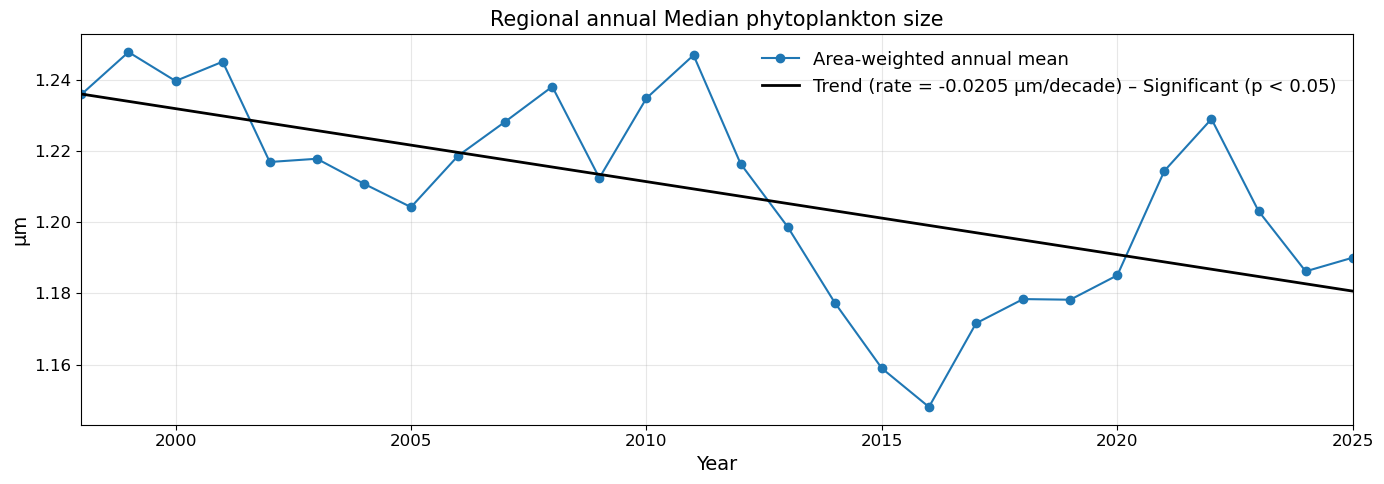

In [9]:
weights = np.cos(np.deg2rad(field.latitude))
regional_monthly = field.weighted(weights).mean(('latitude', 'longitude'))
regional_annual = regional_monthly.resample(time='YS').mean()
x = regional_annual.time.dt.year.values
y = regional_annual.values
valid = np.isfinite(y)
trend_result = stats.linregress(x[valid], y[valid])
slope = trend_result.slope
significant = trend_result.pvalue < 0.05
trend_style = '-' if significant else '--'
significance_text = 'Significant (p < 0.05)' if significant else 'Not significant (p ≥ 0.05)'

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(x, y, marker='o', lw=1.5, label='Area-weighted annual mean')
ax.plot(
    x, trend_result.intercept + slope*x, trend_style, color='black', lw=2,
    label=f'Trend (rate = {slope*10:+.3g} {units}/decade) – {significance_text}',
)
ax.set(xlabel='Year', ylabel=units, title=f'Regional annual {label}')
ax.set_xlim(x[valid].min(), x[valid].max())
ax.grid(alpha=.3); ax.legend(loc='best', frameon=False)
fig.tight_layout()
fig.savefig(fig_dir / f'regional_{variable}_timeseries.png', dpi=180, bbox_inches='tight')

## 6. ENSO modulation

El Niño and La Niña episodes require at least five consecutive months with ONI
above +0.5 °C or below −0.5 °C, respectively. Other months remain Neutral.
Each phase composite is shown as an anomaly from the grid-cell mean over the
complete analysis period, rather than as a difference from the Neutral phase.

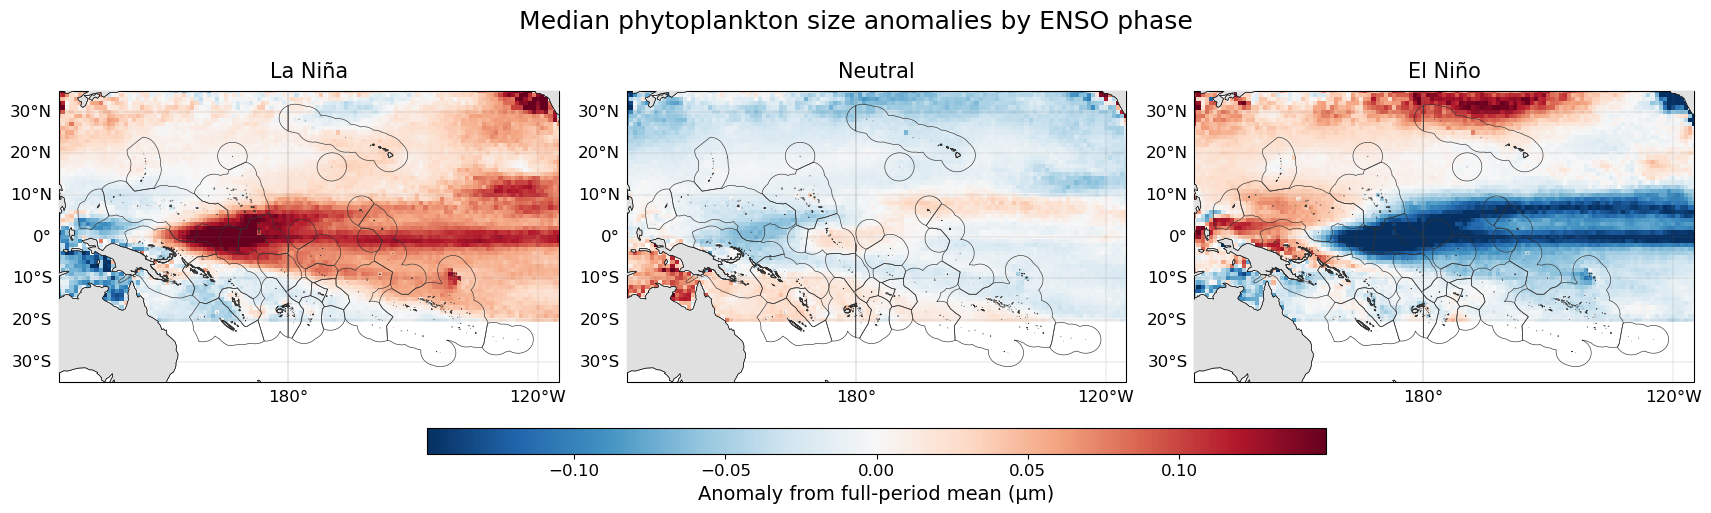

In [10]:
oni_cache = regional_dir / 'oni_index.pkl'
if oni_cache.is_file():
    oni = pd.read_pickle(oni_cache)
else:
    oni = download_oni_index('https://psl.noaa.gov/data/correlation/oni.data')
    oni.to_pickle(oni_cache)
oni = oni.rename(columns={oni.columns[0]: 'ONI'})[['ONI']].copy()

def sustained(mask, minimum=5):
    groups = mask.ne(mask.shift()).cumsum()
    lengths = mask.groupby(groups).transform('sum')
    return mask & (lengths >= minimum)

oni['phase'] = 'Neutral'
oni.loc[sustained(oni.ONI >= .5), 'phase'] = 'El Nino'
oni.loc[sustained(oni.ONI <= -.5), 'phase'] = 'La Nina'
monthly_phase = oni.phase.reindex(pd.DatetimeIndex(field.time.values).to_period('M').to_timestamp())
phase_code = monthly_phase.map({'La Nina': -1, 'Neutral': 0, 'El Nino': 1}).fillna(0).to_numpy()
field_with_phase = field.assign_coords(ENSO=('time', phase_code))
phase_names = {-1: 'La Niña', 0: 'Neutral', 1: 'El Niño'}
full_period_mean = field.mean('time')
phase_means = {phase_names[k]: field_with_phase.where(field_with_phase.ENSO == k, drop=True).mean('time') for k in phase_names}
phase_anomalies = {phase: values - full_period_mean for phase, values in phase_means.items()}

fig, axes = plt.subplots(1, 3, figsize=(17, 5),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}, constrained_layout=True)
all_values = np.concatenate([v.values.ravel() for v in phase_anomalies.values()])
finite_values = all_values[np.isfinite(all_values)]
limit = float(np.nanpercentile(np.abs(finite_values), 98))
for ax, (phase, values) in zip(axes, phase_anomalies.items()):
    setup_map(ax, phase)
    im = ax.pcolormesh(values.longitude, values.latitude, values, transform=ccrs.PlateCarree(),
                       cmap='RdBu_r', vmin=-limit, vmax=limit, shading='auto')
fig.suptitle(f'{label} anomalies by ENSO phase', fontsize=18)
cb = fig.colorbar(
    im, ax=axes, orientation='horizontal', pad=0.06,
    shrink=0.55, aspect=35,
)
cb.set_label(f'Anomaly from full-period mean ({units})', fontsize=14)
fig.savefig(fig_dir / f'regional_{variable}_enso_anomalies.png', dpi=180, bbox_inches='tight')

## 7. EEZ summaries

In [11]:
lon2d, lat2d = np.meshgrid(field.longitude.values, field.latitude.values)
geometry_lon = np.where(lon2d.ravel() > 180, lon2d.ravel() - 360, lon2d.ravel())
points = gpd.GeoDataFrame(
    {'row': np.repeat(np.arange(field.sizes['latitude']), field.sizes['longitude']),
     'col': np.tile(np.arange(field.sizes['longitude']), field.sizes['latitude'])},
    geometry=gpd.points_from_xy(geometry_lon, lat2d.ravel()), crs=4326)
joined = gpd.sjoin(points, eez[[country_col, 'geometry']], predicate='within', how='inner')

rows = []
for country, group in joined.groupby(country_col):
    jj, ii = group.row.to_numpy(), group.col.to_numpy()
    w = np.cos(np.deg2rad(field.latitude.values[jj]))
    mean_values = climatology.values[jj, ii]
    trend_values = trend.values[jj, ii]
    good_mean = np.isfinite(mean_values)
    good_trend = np.isfinite(trend_values)
    rows.append({
        'EEZ': country,
        f'Mean ({units})': np.average(mean_values[good_mean], weights=w[good_mean]) if good_mean.any() else np.nan,
        f'Trend ({units}/decade)': np.average(trend_values[good_trend], weights=w[good_trend]) if good_trend.any() else np.nan,
        'Grid cells': int(good_mean.sum()),
    })
eez_summary = pd.DataFrame(rows).sort_values('EEZ').reset_index(drop=True)
if eez_summary.empty:
    print('No EEZ contains a grid-cell centre at the current data resolution.')
else:
    display(eez_summary.style.format(precision=3))

,EEZ,Mean (µm),Trend (µm/decade),Grid cells
0,American Samoa,0.875,-0.240,33
1,Cook Islands,0.955,-0.417,134
2,Fiji,1.069,-0.003,73
3,French Polynesia,1.074,-0.167,242
4,Hawaii,1.124,-0.663,214
5,Howland Island and Baker Island,1.349,-0.570,34
6,Jarvis Island,1.427,-0.922,25
7,Johnston Atoll,0.955,-0.608,38
8,Kiribati,1.262,-0.237,84
9,Line Group,1.279,-0.756,140


## Interpretation notes

- The regional mean uses cosine-of-latitude weights.
- EEZ statistics assign grid-cell centres to polygons; very small EEZs can have no
  cells when the input is coarse.
- Trends are descriptive ordinary least-squares trends and do not account for
  temporal autocorrelation.
- Data source: [NOAA PIFSC experimental MD50 product](https://oceanwatch.pifsc.noaa.gov/erddap/info/md50_exp_2025/index.html).
